In [ ]:
import numpy as np
import pathlib,cv2,PIL
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
train_path = pathlib.Path("./dogs_vs_cats/train")

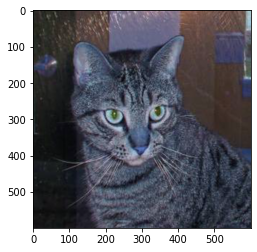

In [ ]:
train_cats = list(train_path.glob("cats/*"))
train_dogs = list(train_path.glob("dogs/*"))

img = cv2.imread(str(train_cats[1]))
resized_img = cv2.resize(img,(600,600))
plt.imshow(resized_img/255.0)

In [ ]:
img_size= (224,224)
x,y=[],[]
train_image_dict= {"cats":train_cats,"dogs":train_dogs}
train_labels_dict={"cats":0,"dogs":1}

In [ ]:
for label,images in train_image_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        r_img =cv2.resize(img,img_size)
        x.append(r_img)
        y.append(train_labels_dict[label])

In [ ]:
test_path = pathlib.Path("./dogs_vs_cats/test")
test_cats = list(test_path.glob("cats/*"))
test_dogs = list(test_path.glob("dogs/*"))

In [ ]:
len(test_cats),len(test_dogs)

(2500, 2500)

In [ ]:
x_test,y_test=[],[]
test_image_dict= {"cats":test_cats,"dogs":test_dogs}
test_labels_dict={"cats":0,"dogs":1}

In [ ]:
for label,images in test_image_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        r_img =cv2.resize(img,img_size)
        x_test.append(r_img)
        y_test.append(test_labels_dict[label])

In [ ]:
X_train = np.array(x) / 255.0
x_test = np.array(x_test)/255.0
y_train = y

In [ ]:
X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.int32)

In [ ]:
y_test = np.array(y_test,dtype=np.int32)

In [ ]:
x_test = np.array(x_test,dtype=np.float32)

In [ ]:
import tensorflow_hub as hub

mobilenet = tf.keras.Sequential([hub.KerasLayer("https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/140-224-feature-vector/2",input_shape=img_size+(3,),trainable=False)])

In [ ]:
model = tf.keras.Sequential([
    mobilenet,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),  
    tf.keras.layers.Dense(128, activation='relu'),  
    tf.keras.layers.Dense(1, activation='sigmoid')  
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential (Sequential)      (None, 1792)              4363712   
_________________________________________________________________
flatten (Flatten)            (None, 1792)              0         
_________________________________________________________________
dropout (Dropout)            (None, 1792)              0         
_________________________________________________________________
dense (Dense)                (None, 128)               229504    
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 129       
Total params: 4,593,345
Trainable params: 229,633
Non-trainable params: 4,363,712
_________________________________________________________________


In [ ]:
model.fit(X_train,y_train,epochs=5)

Epoch 1/5
625/625 [==============================] - 1241s 2s/step - loss: 0.0630 - accuracy: 0.9785
Epoch 2/5
625/625 [==============================] - 1219s 2s/step - loss: 0.0433 - accuracy: 0.9844
Epoch 3/5
625/625 [==============================] - 1217s 2s/step - loss: 0.0365 - accuracy: 0.9858
Epoch 4/5
625/625 [==============================] - 851s 1s/step - loss: 0.0337 - accuracy: 0.9872
Epoch 5/5
625/625 [==============================] - 835s 1s/step - loss: 0.0307 - accuracy: 0.9886


In [ ]:
model.evaluate(x_test,y_test,batch_size=32)

157/157 [==============================] - 202s 1s/step - loss: 0.0395 - accuracy: 0.9854


[0.03953545168042183, 0.9854000210762024]

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred

In [34]:
yp = [1 if y_pred[x] > 0.5 else 0 for x in range(len(y_pred))]


In [38]:
y_test[3330],yp[3330]

(1, 1)

In [36]:
len(y_pred)

5000

<AxesSubplot:>

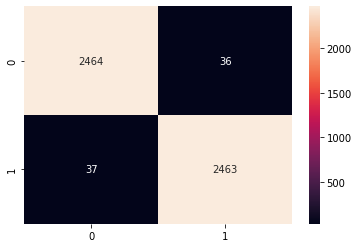

In [44]:
sns.heatmap(tf.math.confusion_matrix(y_test,yp),annot=True,fmt='d')

In [28]:
# test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
# test_dataset = test_dataset.batch(32)  # Use smaller batches

# # Evaluate on Dataset
# model.evaluate(test_dataset)